# SwiGLU Tabular ResNet - PS-S06E09: Electric Vehicle Purchases

This notebook implements an optimized PyTorch **SwiGLU Tabular ResNet** model for Kaggle Playground Series Season 6 Episode 9, predicting the binary target `Will_Buy_EV` (`Yes` / `No`).

Key architecture & setup:
* **Shared Utilities**: Leverages `ExperimentSetup`, `FeatureFactory`, and `ModelVisualizer`.
* **Preprocessing Pipeline**: Categorical entity embeddings, median imputation, and Standard Scaling (`StandardScaler`).
* **SwiGLU Architecture**: Layer Normalization, SwiGLU feature gating (`SiLU(W1*x) * W2*x`), and residual skip connections with dropout.
* **Multi-Seed Ensembling**: Models evaluated across 5 stratified folds and multiple random seeds.
* **Prediction Export**: OOF and test probabilities saved to `predictions/nn_tabular_resnet_oof_probs.csv` and `predictions/nn_tabular_resnet_test_probs.csv` for downstream blending.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import copy
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_feature_engineering import FeatureFactory
from ps_s06e09_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on device: {device}', flush=True)

Training on device: cuda


In [2]:
setup = ExperimentSetup(
    model_name='NN_TabularResNet',
    use_gpu=torch.cuda.is_available(),
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

print(f'Train shape: {training_df.shape}', flush=True)
print(f'Test shape:  {test_df.shape}', flush=True)

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'ev_ratios',
    'charging_accessibility',
    'financial_incentives',
    'range_anxiety_interactions',
    'buyer_readiness_score',
    'income_age_benchmarks',
    'missing_flags',
    'numeric_expansion',
    'group_aggregations',
]

print('Performing feature engineering...', flush=True)
ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].map({'Yes': 1, 'No': 0})

X_test = ff.transform(test_df)

print(f'Engineered Train shape: {X.shape}', flush=True)
print(f'Engineered Test shape:  {X_test.shape}', flush=True)

Performing feature engineering...
  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, numeric_expansion, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding financial incentive features...
  -> Adding range anxiety interaction features...
  -> Adding buyer readiness score features...
  -> Adding income and age benchmark features...
  -> Expanding numeric features...
  -> Adding group aggregation features...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, numeric_expansion, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical v

## 4. PyTorch Dataset & Preprocessing Encoders Setup

In [5]:
class TabularDataset(Dataset):
    def __init__(self, X_num, X_cat, y=None):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X_num)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X_num[idx], self.X_cat[idx], self.y[idx]
        return self.X_num[idx], self.X_cat[idx]

def fit_nn_encoders(X_train, X_test, cat_cols):
    X_all = pd.concat([X_train[cat_cols], X_test[cat_cols]], axis=0, ignore_index=True)
    
    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna('__nan__')
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))
        
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {
        'cat_cols': cat_cols,
        'num_cols': num_cols,
        'cat_maps': cat_maps,
        'cat_dims': cat_dims
    }

def transform_with_encoders(X, fitted):
    cat_cols = fitted['cat_cols']
    num_cols = fitted['num_cols']
    cat_maps = fitted['cat_maps']
    
    X_num = X[num_cols].to_numpy(dtype=np.float32)
    
    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna('__nan__')
        X_cat[:, j] = s.map(m).fillna(0).to_numpy(dtype=np.int64)
        
    return X_num, X_cat

# Global encoding & normalization
print('Precomputing categorical encodings, median imputation, and StandardScaler...', flush=True)
cat_cols = ff.get_cat_features(X)
fitted_encoders = fit_nn_encoders(X, X_test, cat_cols)

X_num_np, X_cat_np = transform_with_encoders(X, fitted_encoders)
Xte_num_np, Xte_cat_np = transform_with_encoders(X_test, fitted_encoders)

imputer = SimpleImputer(strategy='median')
X_num_np = imputer.fit_transform(X_num_np)
Xte_num_np = imputer.transform(Xte_num_np)

scaler = StandardScaler()
X_num_np = scaler.fit_transform(X_num_np)
Xte_num_np = scaler.transform(Xte_num_np)

cat_dims = [(n, min(32, max(4, int(np.ceil(np.sqrt(n) * 2))))) for n in fitted_encoders['cat_dims']]
num_dim = X_num_np.shape[1]
print(f'Preprocessed Numeric features dim: {num_dim}, Categorical features dim: {len(cat_dims)}', flush=True)

Precomputing categorical encodings, median imputation, and StandardScaler...
Preprocessed Numeric features dim: 118, Categorical features dim: 6


## 5. Model Architecture

In [6]:
class SwiGLUResNetBlock(nn.Module):
    def __init__(self, dim, hidden_dim, dropout):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.w1 = nn.Linear(dim, hidden_dim)
        self.w2 = nn.Linear(dim, hidden_dim)
        self.w3 = nn.Linear(hidden_dim, dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = F.silu(self.w1(x)) * self.w2(x)  # SwiGLU feature gating
        x = self.dropout(x)
        x = self.w3(x)
        return residual + x

class SwiGLUTabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, hidden_dim=256, dropout_rate=0.10, num_blocks=4):
        super().__init__()
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim) for num_cats, emb_dim in cat_dims
        ])
        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        
        self.num_proj = nn.Linear(num_dim, hidden_dim - total_cat_dim if total_cat_dim > 0 else hidden_dim)
        self.input_layer = nn.Linear(hidden_dim, hidden_dim)
        
        self.blocks = nn.ModuleList([
            SwiGLUResNetBlock(hidden_dim, hidden_dim * 2, dropout_rate)
            for _ in range(num_blocks)
        ])
        
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_num, x_cat):
        cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        num_emb = self.num_proj(x_num)
        
        if cat_embs:
            x = torch.cat(cat_embs + [num_emb], dim=1)
        else:
            x = num_emb
            
        x = self.input_layer(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x).squeeze(-1)

## 6. Training & Validation Loop

Trains the model across 5 Stratified CV folds and averages predictions over multiple seeds to reduce prediction variance.

In [7]:
BATCH_SIZE = 1024
EPOCHS = 100
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
ES_PATIENCE = 15
n_splits = 5

seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.ones(len(X), dtype=bool)

test_ds = TabularDataset(Xte_num_np, Xte_cat_np, np.zeros(len(Xte_num_np)))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False, drop_last=False)

for seed_idx, run_seed in enumerate(seeds):
    print(f"\n{'='*20} SEED {run_seed} ({seed_idx+1}/{len(seeds)}) {'='*20}", flush=True)
    setup.set_seeds(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)
        
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run_seed)
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_num_np, y)):
        print(f"\n--- Seed {run_seed} | Fold {fold+1}/{n_splits} ---", flush=True)
        
        Xtr_num_np, Xtr_cat_np, y_tr = X_num_np[tr_idx], X_cat_np[tr_idx], y.iloc[tr_idx].values
        Xva_num_np, Xva_cat_np, y_val = X_num_np[val_idx], X_cat_np[val_idx], y.iloc[val_idx].values
        
        train_ds = TabularDataset(Xtr_num_np, Xtr_cat_np, y_tr)
        val_ds = TabularDataset(Xva_num_np, Xva_cat_np, y_val)
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
        
        model = SwiGLUTabularResNet(
            num_dim=num_dim,
            cat_dims=cat_dims,
            hidden_dim=256,
            num_blocks=4,
            dropout_rate=0.10
        ).to(device)
        
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        criterion = nn.BCEWithLogitsLoss()
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)
        
        best_val_auc = -1.0
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        
        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            
            for batch_num, batch_cat, batch_y in train_loader:
                batch_num, batch_cat, batch_y = batch_num.to(device), batch_cat.to(device), batch_y.to(device).float()
                
                optimizer.zero_grad()
                logits = model(batch_num, batch_cat)
                loss = criterion(logits, batch_y)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * batch_num.size(0)
                
            epoch_loss = running_loss / len(train_loader.dataset)
            
            # Evaluation
            model.eval()
            val_preds_list = []
            val_targets_list = []
            
            with torch.no_grad():
                for batch_num, batch_cat, batch_y in val_loader:
                    batch_num, batch_cat = batch_num.to(device), batch_cat.to(device)
                    logits = model(batch_num, batch_cat)
                    probs = torch.sigmoid(logits)
                    val_preds_list.extend(probs.cpu().numpy())
                    val_targets_list.extend(batch_y.numpy())
                    
            val_auc = roc_auc_score(val_targets_list, val_preds_list)
            current_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_auc)
            
            if val_auc > best_val_auc + 1e-6:
                best_val_auc = val_auc
                best_model_weights = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                
            if (epoch + 1) % 10 == 0 or epoch == 0 or patience_counter >= ES_PATIENCE:
                print(f"    Epoch {epoch+1:03d} | Loss: {epoch_loss:.4f} | Val ROC AUC: {val_auc:.6f} | LR: {current_lr:.6f}", flush=True)
                
            if patience_counter >= ES_PATIENCE:
                print(f"    Early stopping at epoch {epoch+1:03d} (Best Val AUC: {best_val_auc:.6f})", flush=True)
                break
                
        print(f"    Fold {fold+1} Best ROC AUC: {best_val_auc:.6f}", flush=True)
        
        # Load best model for fold OOF and test inference
        model.load_state_dict(best_model_weights)
        model.eval()
        
        fold_oof_probs = []
        with torch.no_grad():
            for batch_num, batch_cat, _ in val_loader:
                batch_num, batch_cat = batch_num.to(device), batch_cat.to(device)
                probs = torch.sigmoid(model(batch_num, batch_cat))
                fold_oof_probs.extend(probs.cpu().numpy())
                
        fold_oof_probs = np.array(fold_oof_probs)
        oof_probs[val_idx, 1] += fold_oof_probs / len(seeds)
        oof_probs[val_idx, 0] += (1.0 - fold_oof_probs) / len(seeds)
        
        fold_test_probs = []
        with torch.no_grad():
            for batch_num, batch_cat, _ in test_loader:
                batch_num, batch_cat = batch_num.to(device), batch_cat.to(device)
                probs = torch.sigmoid(model(batch_num, batch_cat))
                fold_test_probs.extend(probs.cpu().numpy())
                
        fold_test_probs = np.array(fold_test_probs)
        test_probs[:, 1] += fold_test_probs / (n_splits * len(seeds))
        test_probs[:, 0] += (1.0 - fold_test_probs) / (n_splits * len(seeds))

final_oof_probs = oof_probs[:, 1]
final_auc = roc_auc_score(y, final_oof_probs)

print("\n" + "="*60, flush=True)
print(f"SwiGLU Tabular ResNet Multi-Seed Seed-Averaged CV ROC AUC: {final_auc:.6f}", flush=True)
print("="*60, flush=True)


==================== SEED 10301 (1/5) ====================
Random seed set to: 10301

--- Seed 10301 | Fold 1/5 ---
    Epoch 001 | Loss: 0.2401 | Val ROC AUC: 0.936089 | LR: 0.002000
    Epoch 010 | Loss: 0.2316 | Val ROC AUC: 0.937357 | LR: 0.001000
    Epoch 020 | Loss: 0.2310 | Val ROC AUC: 0.937426 | LR: 0.000500
    Epoch 030 | Loss: 0.2301 | Val ROC AUC: 0.937633 | LR: 0.000125
    Epoch 040 | Loss: 0.2297 | Val ROC AUC: 0.937660 | LR: 0.000031
    Epoch 050 | Loss: 0.2296 | Val ROC AUC: 0.937659 | LR: 0.000008
    Epoch 052 | Loss: 0.2295 | Val ROC AUC: 0.937663 | LR: 0.000008
    Early stopping at epoch 052 (Best Val AUC: 0.937678)
    Fold 1 Best ROC AUC: 0.937678

--- Seed 10301 | Fold 2/5 ---
    Epoch 001 | Loss: 0.2404 | Val ROC AUC: 0.937873 | LR: 0.002000
    Epoch 010 | Loss: 0.2332 | Val ROC AUC: 0.938918 | LR: 0.002000
    Epoch 020 | Loss: 0.2316 | Val ROC AUC: 0.939202 | LR: 0.000500
    Epoch 030 | Loss: 0.2309 | Val ROC AUC: 0.939294 | LR: 0.000250
    Epoch 040

## 7. Performance Visualization

<Figure size 800x600 with 0 Axes>

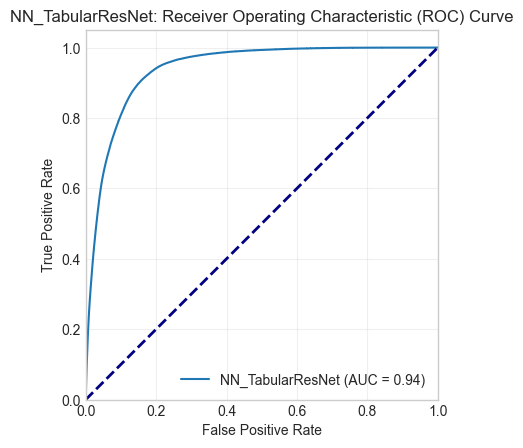

In [8]:
mviz = ModelVisualizer(model_name='NN_TabularResNet')
mviz.plot_roc_curve(y_true=y, y_score=oof_probs[:, 1])

Confusion matrix, without normalization


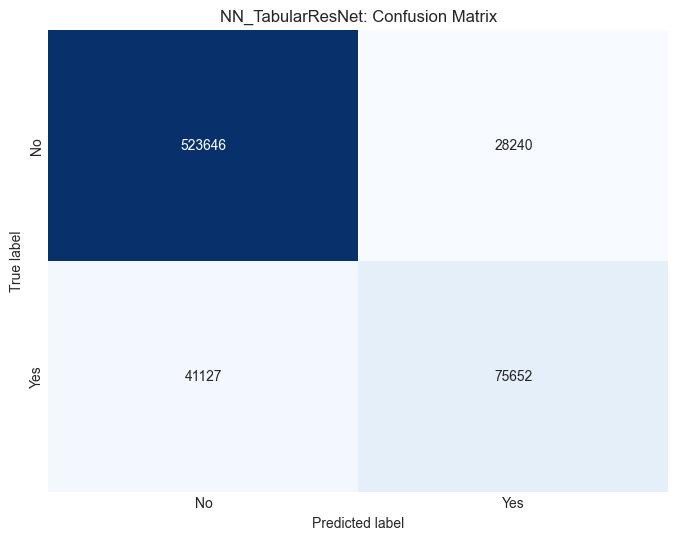

In [9]:
y_pred_class = (oof_probs[:, 1] >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_pred_class, classes=['No', 'Yes'])

## 8. Export Submission & Predictions

In [10]:
submission_df = setup.read_dataset('submission')
submission_df[TARGET] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully!', flush=True)

setup.save_probabilities('nn_tabular_resnet', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/nn_tabular_resnet_oof_probs.csv
 - predictions/nn_tabular_resnet_test_probs.csv
